# Практичесая работа №2

## Часть 1: парсинг

In [85]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import zscore, iqr
from scipy import stats

**Код запроса закоменитрован, чтобы постоянно не повторять его**

In [86]:
# url = "https://www.usinflationcalculator.com/inflation/consumer-price-index-and-annual-percent-changes-from-1913-to-2008/"

# r = requests.get(url)
# data = r.text
# soup = BeautifulSoup(data, "html.parser")

# table = soup.find("table")
# rows = table.tbody.find_all("tr")

# years = []
# cpis = []

# for row in rows:
#     year = row.find_all("td")[0].get_text()
#     if year.isdigit() and int(year) < 2017:
#         years.append(int(year))
#         cpis.append(float(row.find_all("td")[13].get_text()))

# cpi_table = pd.DataFrame(
#     {
#         "year": years,
#         "avg_annual_cpi": cpis
#     }
# )

# cpi_table.head()

# cpi_table.to_csv("../data/Practice2_Baklanov_CPI.csv")

cpi_table = pd.read_csv('../data/Practice2_Baklanov_CPI.csv', sep=",")

cpi_table = cpi_table.drop(columns=["Unnamed: 0"])
cpi_table

,year,avg_annual_cpi
0,1913,9.90
1,1914,10.00
2,1915,10.10
3,1916,10.90
4,1917,12.80
...,...,...
99,2012,229.59
100,2013,232.96
101,2014,236.74
102,2015,237.02


## Часть 2. Очистка данных

In [87]:
movies_table = pd.read_csv("../data/Dataset1.csv")

pd.set_option('display.float_format', '{:,.2f}'.format)

movies_table.head(68)

,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
0,Color,James Cameron,723.00,178.00,0.00,855.00,Joel David Moore,"1,000.00","760,505,847.00",Action|Adventure|Fantasy|Sci-Fi,...,"3,054.00",English,USA,PG-13,"237,000,000.00","2,009.00",936.00,7.90,1.78,33000;
1,Colour,Gore Verbinski,302.00,169.00,563.00,"1,000.00",Orlando Bloom,"40,000.00","309,404,152.00",Action|Adventure|Fantasy,...,"1,238.00",English,USA,PG-13,"300,000,000.00","2,007.00","5,000.00",7.10,2.35,0;
2,Colour,Sam Mendes,602.00,148.00,0.00,161.00,Rory Kinnear,"11,000.00","200,074,175.00",Action|Adventure|Thriller,...,994.00,English,UK,PG-13,"245,000,000.00","2,015.00",393.00,6.80,2.35,85000;
3,Color,Christopher Nolan,813.00,164.00,"22,000.00","23,000.00",Christian Bale,"27,000.00","448,130,642.00",Action|Thriller,...,"2,701.00",English,USA,PG-13,"250,000,000.00","2,012.00","23,000.00",8.50,2.35,164000;
4,NaN,Doug Walker,NaN,NaN,131.00,NaN,Rob Walker,131.00,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.00,7.10,NaN,0;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Color,David Yates,248.00,110.00,282.00,103.00,Alexander Skarsgård,"11,000.00","124,051,759.00",Action|Adventure|Drama|Romance,...,239.00,English,USA,PG-13,"180,000,000.00","2,016.00","10,000.00",6.60,2.35,29000;
64,"Color,Andrew Adamson,284,150,80,82,Kiran Shah,...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65,Color,Bryan Singer,396.00,144.00,0.00,"1,000.00",Michael Fassbender,"34,000.00","154,985,087.00",Action|Adventure|Sci-Fi,...,622.00,English,USA,PG-13,"178,000,000.00","2,016.00","13,000.00",7.30,2.35,54000;
66,Color,Christopher Nolan,645.00,152.00,"22,000.00","11,000.00",Heath Ledger,"23,000.00","533,316,061.00",Action|Crime|Drama|Thriller,...,"4,667.00",English,USA,PG-13,"185,000,000.00","2,008.00","13,000.00",9.00,2.35,37000;


In [88]:
movies_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   color                       5025 non-null   str    
 1   Director_Name               4872 non-null   str    
 2   num_Critic_for_reviews      4927 non-null   float64
 3   duration                    4959 non-null   float64
 4   director_Facebook_likes     4872 non-null   float64
 5   actor_3_Facebook_likes      4953 non-null   float64
 6   actor_2_name                4963 non-null   str    
 7   Actor_1_Facebook_likes      4968 non-null   float64
 8   gross                       4104 non-null   float64
 9   genres                      4974 non-null   str    
 10  actor_1_name                4968 non-null   str    
 11  movie_Title                 4974 non-null   str    
 12  num_voted_users             4974 non-null   float64
 13   cast_total_facebook_likes  4974 non-null   

Видно, что некоторые строки заполненые неправильно - вся информация содержится в 1 атрибуте (как в 64 строчке)

In [89]:
# я пытался реализовать алгоритм разъединения проблемных ячекк, но у меня не поулчилось это сделать. Поэтому я просто удалил такие строки, ввиду их малого количества (69)

mask = movies_table.iloc[:, 0].str.contains(',', na=False)
c = 0
for idx in movies_table[mask].index:
    c+= 1

print(c)

movies_table = movies_table[~mask].reset_index(drop=True)

# так же уберем лишний пробел перед " cast_total_facebook_likes"

movies_table.columns = movies_table.columns.str.strip()

movies_table[movies_table.isnull().any(axis=1)]



69


,color,Director_Name,num_Critic_for_reviews,duration,director_Facebook_likes,actor_3_Facebook_likes,actor_2_name,Actor_1_Facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes;
4,NaN,Doug Walker,NaN,NaN,131.00,NaN,Rob Walker,131.00,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.00,7.10,NaN,0;
55,Color,Peter Sohn,298.00,93.00,113.00,113.00,Jack McGraw,275.00,"123,070,338.00",Adventure|Animation|Comedy|Family|Fantasy,...,345.00,English,USA,PG,NaN,"2,015.00",150.00,6.80,2.35,20000;
83,Color,Roland Joffé,10.00,109.00,596.00,283.00,Alice Englert,622.00,NaN,Action|Adventure|Romance|Sci-Fi,...,15.00,English,Belgium,R,NaN,"2,015.00",525.00,4.50,NaN,677;
97,Color,Hideaki Anno,1.00,120.00,28.00,12.00,Shin'ya Tsukamoto,544.00,NaN,Action|Adventure|Drama|Horror|Sci-Fi,...,13.00,Japanese,Japan,NaN,NaN,"2,016.00",106.00,8.20,2.35,0;
98,Color,Peter Jackson,645.00,182.00,0.00,773.00,Adam Brown,"5,000.00","303,001,229.00",Adventure|Fantasy,...,"1,367.00",English,USA,PG-13,"180,000,000.00","2,012.00",972.00,7.90,2.35,166000;
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4968,Color,Edward Burns,14.00,95.00,0.00,133.00,Caitlin FitzGerald,296.00,"4,584.00",Comedy|Drama,...,14.00,English,USA,Not Rated,"9,000.00","2,011.00",205.00,6.40,NaN,413;
4969,Color,Scott Smith,1.00,87.00,2.00,318.00,Daphne Zuniga,637.00,NaN,Comedy|Drama,...,6.00,English,Canada,NaN,NaN,"2,013.00",470.00,7.70,NaN,84;
4970,Color,NaN,43.00,43.00,NaN,319.00,Valorie Curry,841.00,NaN,Crime|Drama|Mystery|Thriller,...,359.00,English,USA,TV-14,NaN,NaN,593.00,7.50,16.00,32000;
4971,Color,Benjamin Roberds,13.00,76.00,0.00,0.00,Maxwell Moody,0.00,NaN,Drama|Horror|Thriller,...,3.00,English,USA,NaN,"1,400.00","2,013.00",0.00,6.30,NaN,16;


- Поля принимают либо `float`, либо `str` значения
- Во многих атрибутах пропущены данные
- `movie_facebook_likes` на мамом деле представляют собой числа, поэтому могут быть приведены к float

Иcходя из специфики задания, от некоторых атрибутов можно избавиться, ввиду незначимости для исследования:

- `plot_keywords`
- `movie_imbd_link`
- `actor_1_name`, `actor_2_name`, `actor_3_name`
- `facenumber_in_poster`
- `aspect_ratio`
- `language`
- `num_Critic_for_reviews`, `num_user_for_reviews`
- `movie_Title`
- `color`

Эти атрибуты являются:

- Техническими и не влияют на исследования `movie_imbd_link`, `aspect_ratio`
- Рекламными и служат для продвижения и поиска фильма

In [90]:
cols_to_drop = [
    "plot_keywords", 
    "movie_imdb_link", 
    "actor_1_name", 
    "actor_2_name", 
    "actor_3_name",
    "facenumber_in_poster", 
    "aspect_ratio", 
    "language", 
    "num_Critic_for_reviews", 
    "num_user_for_reviews",
    "movie_Title",
    "color"
]

movies_table = movies_table.drop(columns=cols_to_drop)


In [91]:
movies_table['Director_Name'] = movies_table['Director_Name'].fillna('Unknow')


In [92]:
movies_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 4974 entries, 0 to 4973
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Director_Name              4974 non-null   str    
 1   duration                   4959 non-null   float64
 2   director_Facebook_likes    4872 non-null   float64
 3   actor_3_Facebook_likes     4953 non-null   float64
 4   Actor_1_Facebook_likes     4968 non-null   float64
 5   gross                      4104 non-null   float64
 6   genres                     4974 non-null   str    
 7   num_voted_users            4974 non-null   float64
 8   cast_total_facebook_likes  4974 non-null   float64
 9   country                    4971 non-null   str    
 10  content_rating             4677 non-null   str    
 11  budget                     4494 non-null   float64
 12  title_year                 4869 non-null   float64
 13  actor_2_facebook_likes     4963 non-null   float64
 14  imd

В данных остались некотоыре пропуски, поэтому продолжим их устранять:
- Метрики `gross` и `budget` не подчинаются каким-либо правилам (представляют собой абсолютно случайные данные), поэтому как-либо их восстановить почти невозможно -> избавимся от некорректных данных + в дальнейшем не получится сравнивать с Na, а создавая искусственные данные, можно исказить реальные распределения, что сильно повлияет на итоги
- недостающе `str` атрибуты заменим модой 
- Недостающие `float` атрибуты заменим медианой

Пропушенные атрибуты, связанные с `likes` стоит заменить 0, чтобы не создавать искажения (они просто не будут влиять на данные)

Так же надо перевести `movie_facebook_likes` в `float`
Помимо этого возрастная метка `Approved` соотвестует современной `G` (старая шкала)



In [93]:
rename_dict = {}
for col in movies_table.columns:
    if 'facebook_likes' in col.lower():
        new_name = col.replace('facebook_likes', 'Facebook_likes').replace(';', '')
        rename_dict[col] = new_name

print("Переименование колонок:")
for old, new in rename_dict.items():
    print(f"  {old} → {new}")

movies_table = movies_table.rename(columns=rename_dict)

movies_table['content_rating'] = movies_table['content_rating'].replace('Approved', 'G')


Переименование колонок:
  director_Facebook_likes → director_Facebook_likes
  actor_3_Facebook_likes → actor_3_Facebook_likes
  Actor_1_Facebook_likes → Actor_1_Facebook_likes
  cast_total_facebook_likes → cast_total_Facebook_likes
  actor_2_facebook_likes → actor_2_Facebook_likes
  movie_facebook_likes; → movie_Facebook_likes


In [94]:
movies_table = movies_table.dropna(subset=['gross', 'budget'])

# Убираем ';' из всех значений последенй колонки movie_Facebook_likes
movies_table["movie_Facebook_likes"] = movies_table["movie_Facebook_likes"].astype(str).str.replace(';', '', regex=False)
movies_table["movie_Facebook_likes"] = movies_table["movie_Facebook_likes"].astype("float")


for col in movies_table.select_dtypes(include=['str']).columns:
    if movies_table[col].isnull().any():
        movies_table[col] = movies_table[col].fillna(movies_table[col].mode()[0])

for col in movies_table.select_dtypes(include=['float64']).columns:
    if 'Facebook_likes' not in col and movies_table[col].isnull().any():
        movies_table[col] = movies_table[col].fillna(movies_table[col].median())

fb_cols = [col for col in movies_table.columns if 'Facebook_likes' in col]
for col in fb_cols:
    movies_table[col] = movies_table[col].fillna(0)



In [95]:
movies_table.info()

<class 'pandas.DataFrame'>
Index: 3845 entries, 0 to 4973
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Director_Name              3845 non-null   str    
 1   duration                   3845 non-null   float64
 2   director_Facebook_likes    3845 non-null   float64
 3   actor_3_Facebook_likes     3845 non-null   float64
 4   Actor_1_Facebook_likes     3845 non-null   float64
 5   gross                      3845 non-null   float64
 6   genres                     3845 non-null   str    
 7   num_voted_users            3845 non-null   float64
 8   cast_total_Facebook_likes  3845 non-null   float64
 9   country                    3845 non-null   str    
 10  content_rating             3845 non-null   str    
 11  budget                     3845 non-null   float64
 12  title_year                 3845 non-null   float64
 13  actor_2_Facebook_likes     3845 non-null   float64
 14  imdb_sco

Конвертируем некторые `float` атрибуты в `int`

In [96]:
def can_convert_to_int(series):
    if series.isnull().any():
        return False, "Есть пропуски (NaN)"
    
    if not (series == series.astype(int)).all():
        return False, "Есть дробные значения"
    
    return True, "Можно конвертировать"

print("Проверка float-колонок на возможность конвертации в int:\n")

for col in movies_table.select_dtypes(include=['float64']).columns:
    can_convert, reason = can_convert_to_int(movies_table[col])
    print(f"{col}: {reason}")
    if can_convert:
        movies_table[col] = movies_table[col].astype("int")

Проверка float-колонок на возможность конвертации в int:

duration: Можно конвертировать
director_Facebook_likes: Можно конвертировать
actor_3_Facebook_likes: Можно конвертировать
Actor_1_Facebook_likes: Можно конвертировать
gross: Можно конвертировать
num_voted_users: Можно конвертировать
cast_total_Facebook_likes: Можно конвертировать
budget: Можно конвертировать
title_year: Можно конвертировать
actor_2_Facebook_likes: Можно конвертировать
imdb_score: Есть дробные значения
movie_Facebook_likes: Можно конвертировать


In [97]:
movies_table.info()

<class 'pandas.DataFrame'>
Index: 3845 entries, 0 to 4973
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Director_Name              3845 non-null   str    
 1   duration                   3845 non-null   int64  
 2   director_Facebook_likes    3845 non-null   int64  
 3   actor_3_Facebook_likes     3845 non-null   int64  
 4   Actor_1_Facebook_likes     3845 non-null   int64  
 5   gross                      3845 non-null   int64  
 6   genres                     3845 non-null   str    
 7   num_voted_users            3845 non-null   int64  
 8   cast_total_Facebook_likes  3845 non-null   int64  
 9   country                    3845 non-null   str    
 10  content_rating             3845 non-null   str    
 11  budget                     3845 non-null   int64  
 12  title_year                 3845 non-null   int64  
 13  actor_2_Facebook_likes     3845 non-null   int64  
 14  imdb_sco

После устранения пропущенных данных, можно приступить к конвертации `gros` и `budget`, согласно инфляции. Эти столбцы будут сразы заменены на реальные

In [98]:
def get_real_value(nominal_amt, old_cpi, new_cpi):
    real_value = (nominal_amt * new_cpi) / old_cpi
    return real_value

CPI_2016 = float(cpi_table[cpi_table['year'] == 2016]['avg_annual_cpi'].values[0])

real_domestic_gross = []
real_budget_values = []

for index, row in movies_table.iterrows():
    gross = row['gross']
    budget = row['budget']
    year = row['title_year']
    cpi = float(cpi_table[cpi_table['year'] == int(year)]['avg_annual_cpi'].values[0])
    
    real_gross = get_real_value(gross, cpi, CPI_2016)
    real_budget = get_real_value(budget, cpi, CPI_2016)
    real_domestic_gross.append(real_gross)
    real_budget_values.append(real_budget)

movies_table["real_domestic_gross"] = real_domestic_gross
movies_table["real_budget"] = real_budget_values

profits = []
roi_vals = []

for index, row in movies_table.iterrows():
    profit = row['real_domestic_gross'] - row['real_budget']
    budget = row['real_budget']
    num = profit - budget
    den = budget
    
    roi = (num / den) * 100
    
    profits.append(profit)
    roi_vals.append(roi)

movies_table['profit'] = profits
movies_table['roi'] = roi_vals

movies_table['real_budget'] = movies_table['real_budget']
movies_table['real_domestic_gross'] = movies_table['real_domestic_gross']
movies_table['profit'] = movies_table['profit']

movies_table = movies_table.drop(columns=['gross', 'budget'])


В таких данных дубликатов быть не может. Их наличие является ошибкой

In [99]:
print(f"дубликатов: {movies_table.duplicated().sum()}")

movies_table = movies_table.drop_duplicates(keep='first')

дубликатов: 34


In [100]:
movies_table

,Director_Name,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,genres,num_voted_users,cast_total_Facebook_likes,country,content_rating,title_year,actor_2_Facebook_likes,imdb_score,movie_Facebook_likes,real_domestic_gross,real_budget,profit,roi
0,James Cameron,178,0,855,1000,Action|Adventure|Fantasy|Sci-Fi,886204,4834,USA,PG-13,2009,936,7.90,33000,"850,793,694.43","265,136,824.88","585,656,869.54",120.89
1,Gore Verbinski,169,563,1000,40000,Action|Adventure|Fantasy,471220,48350,USA,PG-13,2007,5000,7.10,0,"358,220,754.02","347,332,850.94","10,887,903.08",-96.87
2,Sam Mendes,148,0,161,11000,Action|Adventure|Thriller,275868,11700,UK,PG-13,2015,393,6.80,85000,"202,598,136.50","248,090,706.57","-45,492,570.07",-118.34
3,Christopher Nolan,164,22000,23000,27000,Action|Thriller,1144337,106759,USA,PG-13,2012,23000,8.50,164000,"468,455,146.89","261,338,493.17","207,116,653.72",-20.75
5,Andrew Stanton,132,475,530,640,Action|Adventure|Sci-Fi,212204,1873,USA,PG-13,2012,632,6.60,24000,"76,372,180.33","275,659,842.59","-199,287,662.26",-172.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4964,Shane Carruth,77,291,8,291,Drama|Sci-Fi|Thriller,72639,368,USA,PG-13,2004,45,7.00,19000,"539,679.05","8,893.85","530,785.20","5,868.00"
4965,Neill Dela Llana,80,0,0,0,Thriller,589,0,Philippines,Not Rated,2005,0,6.30,74,"86,111.27","8,602.40","77,508.87",801.01
4966,Robert Rodriguez,81,0,6,121,Action|Crime|Drama|Romance|Thriller,52055,147,USA,R,1992,20,6.90,0,"3,491,340.60","11,974.69","3,479,365.91","28,956.00"
4968,Edward Burns,95,0,133,296,Comedy|Drama,1338,690,USA,Not Rated,2011,205,6.40,413,"4,891.07","9,602.88","-4,711.81",-149.07


In [101]:
movies_table.info()

<class 'pandas.DataFrame'>
Index: 3811 entries, 0 to 4973
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Director_Name              3811 non-null   str    
 1   duration                   3811 non-null   int64  
 2   director_Facebook_likes    3811 non-null   int64  
 3   actor_3_Facebook_likes     3811 non-null   int64  
 4   Actor_1_Facebook_likes     3811 non-null   int64  
 5   genres                     3811 non-null   str    
 6   num_voted_users            3811 non-null   int64  
 7   cast_total_Facebook_likes  3811 non-null   int64  
 8   country                    3811 non-null   str    
 9   content_rating             3811 non-null   str    
 10  title_year                 3811 non-null   int64  
 11  actor_2_Facebook_likes     3811 non-null   int64  
 12  imdb_score                 3811 non-null   float64
 13  movie_Facebook_likes       3811 non-null   int64  
 14  real_dom

In [102]:
movies_table.describe()

,duration,director_Facebook_likes,actor_3_Facebook_likes,Actor_1_Facebook_likes,num_voted_users,cast_total_Facebook_likes,title_year,actor_2_Facebook_likes,imdb_score,movie_Facebook_likes,real_domestic_gross,real_budget,profit,roi
count,"3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00","3,811.00"
mean,109.84,792.06,747.59,"7,573.48","102,344.99","11,245.51","2,003.08","1,963.32",6.46,"9,130.05","73,096,328.00","57,535,975.01","15,560,352.99",429.10
std,22.48,"3,043.12","1,846.83","15,442.17","150,351.41","18,965.02",9.96,"4,481.51",1.05,"21,367.81","132,985,066.46","272,864,362.88","296,990,053.57","13,095.12"
min,34.00,0.00,0.00,0.00,5.00,0.00,"1,920.00",0.00,1.60,0.00,164.24,284.36,"-14,540,065,249.06",-200.00
25%,95.00,10.00,182.00,721.00,"17,284.50","1,824.00","1,999.00",363.00,5.90,0.00,"8,931,561.58","12,965,564.23","-13,484,564.19",-154.75
50%,106.00,58.00,426.00,"1,000.00","50,653.00","3,889.00","2,005.00",664.00,6.60,204.00,"36,383,120.15","31,763,763.90","1,152,158.83",-93.41
75%,120.00,226.00,687.00,"12,000.00","124,062.50","15,994.50","2,010.00",971.00,7.20,"11,000.00","88,114,721.79","67,123,246.81","33,302,848.88",22.16
max,325.00,"23,000.00","23,000.00","640,000.00","1,689,764.00","656,730.00","2,016.00","137,000.00",9.30,"349,000.00","3,430,119,230.72","14,542,686,054.07","3,361,449,602.01","719,248.55"


C:\Users\danii\AppData\Local\Temp\ipykernel_16836\962089070.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend()


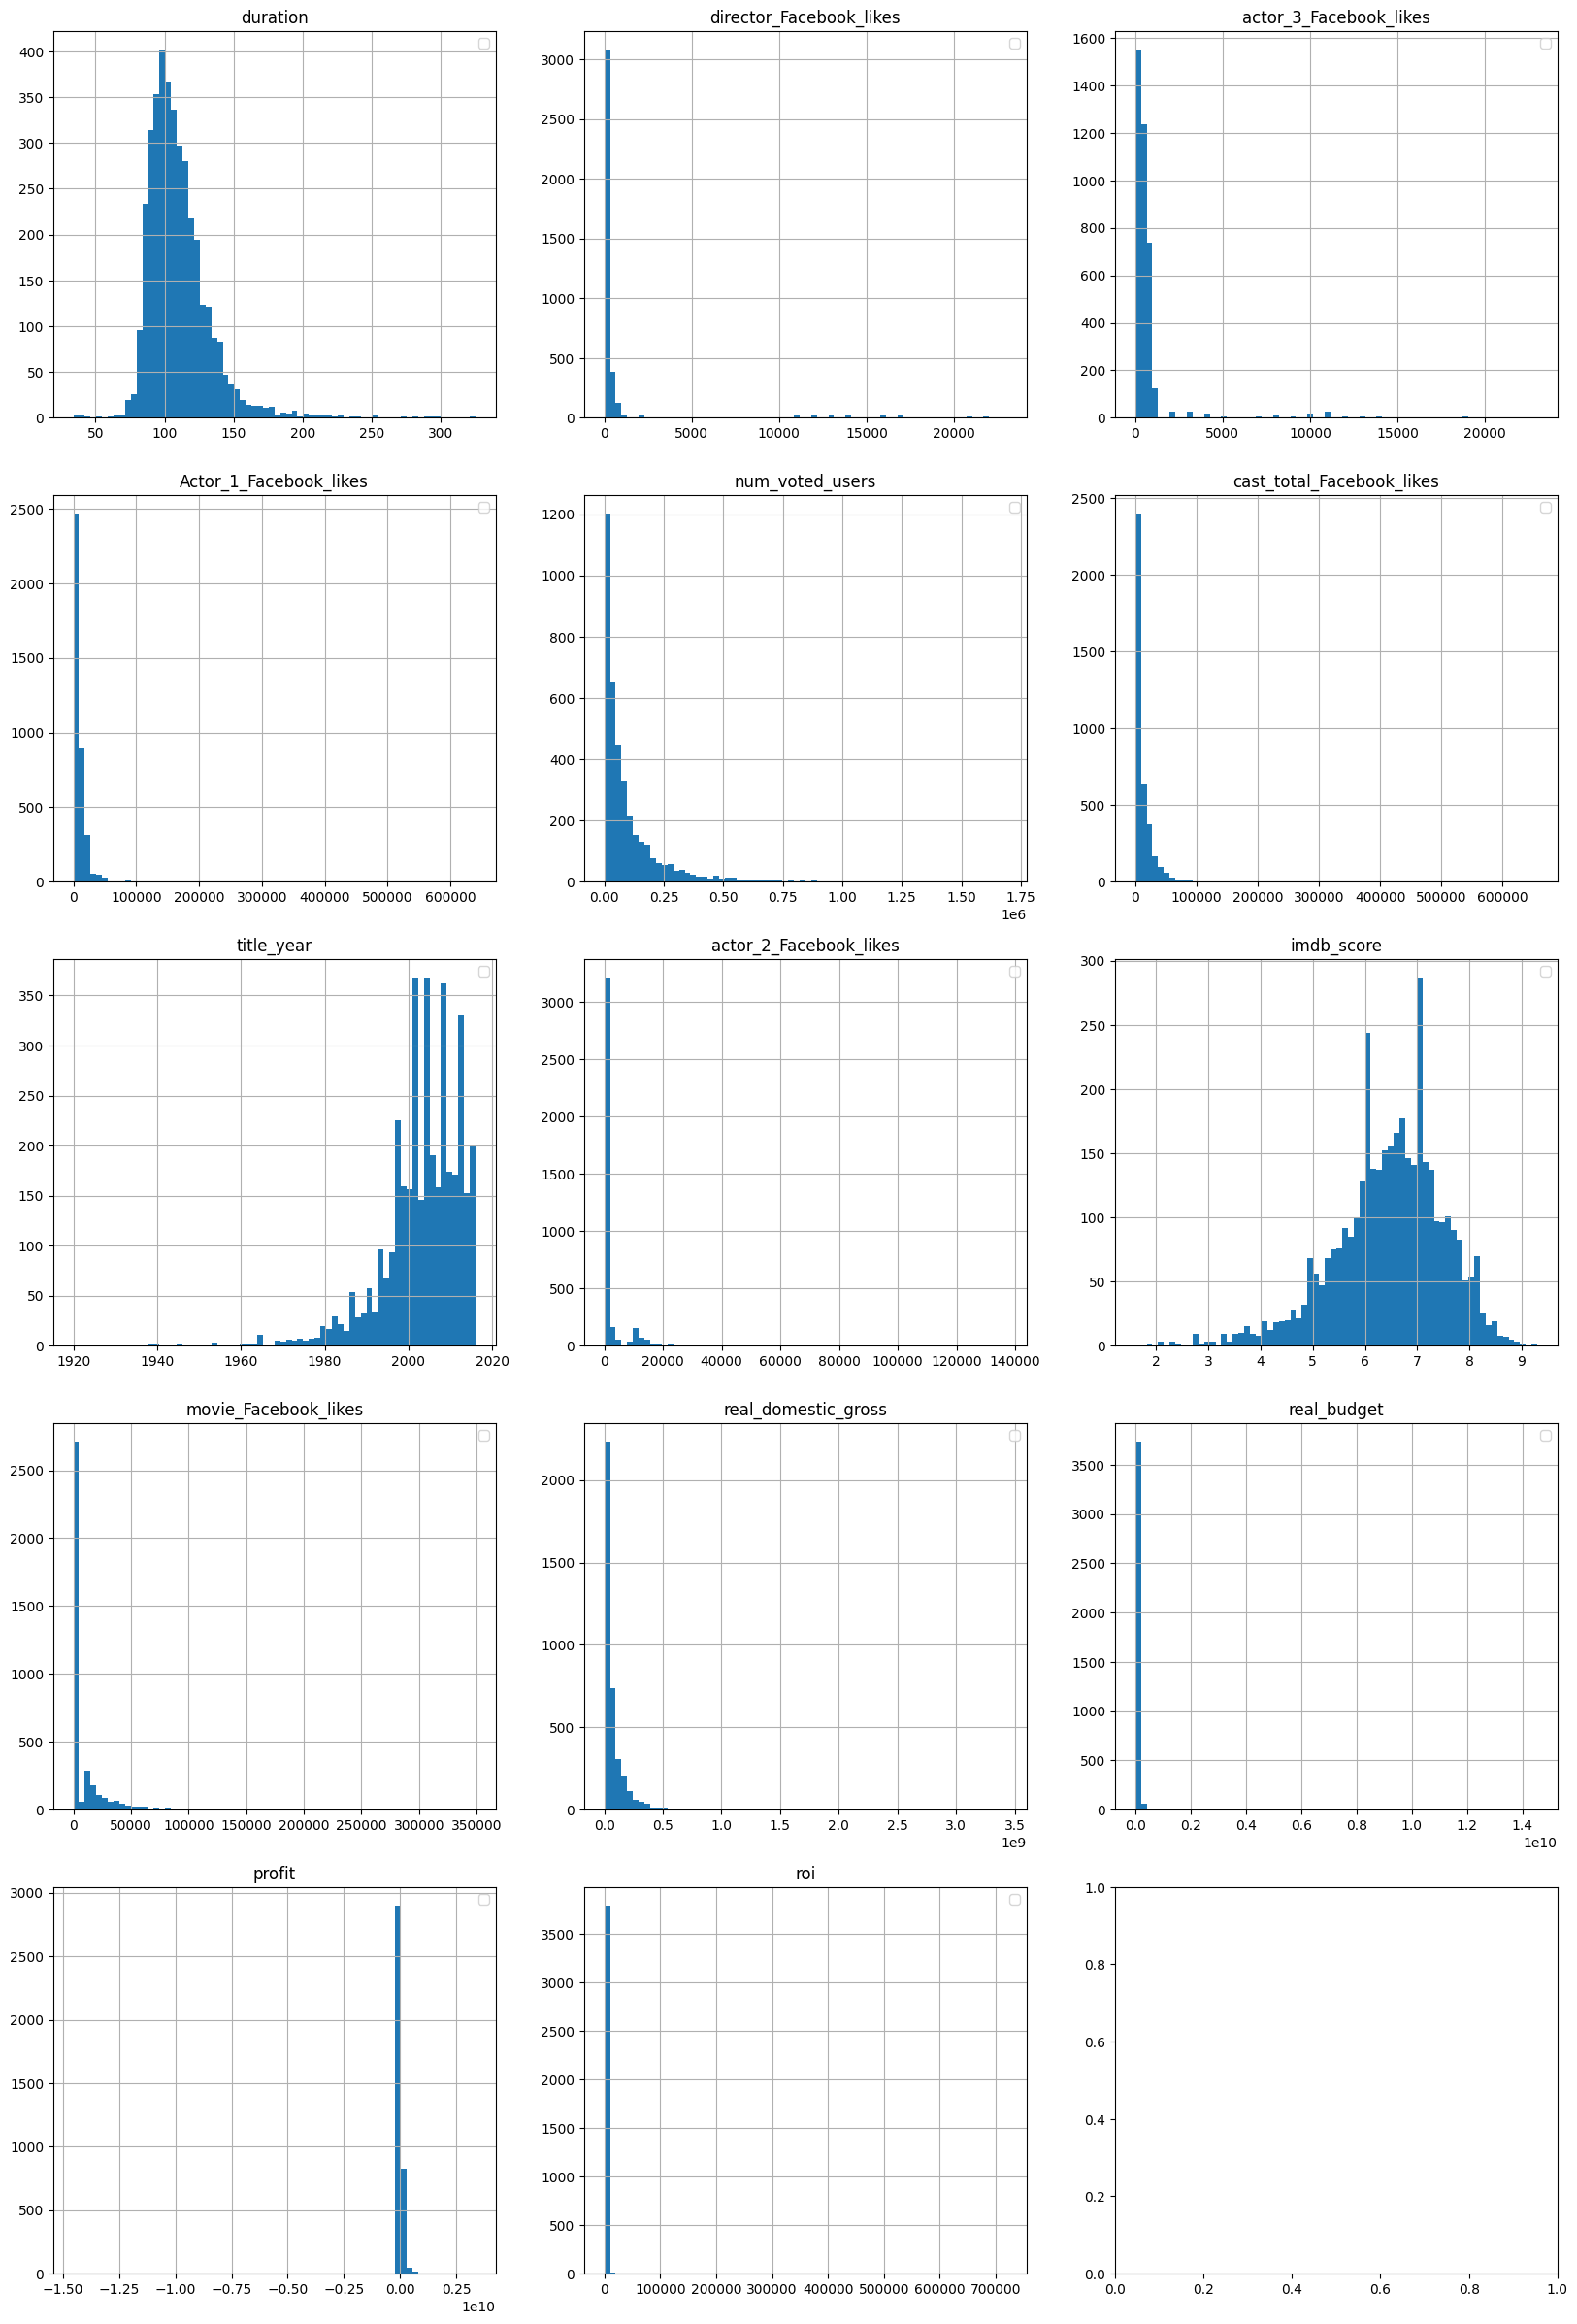

In [117]:
fig, axes = plt.subplots(5, 3, figsize=(20, 30))
axes = axes.flatten()

numeric_cols = movies_table.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    movies_table[col].hist(ax=axes[i], bins=70)
    axes[i].set_title(col)
    axes[i].legend()

**Итоги этапа**

- Все данные не содержат пропуски
- `float` зачения конвертированы в `int`
- Добавлены `real_budget`, `real_domestic_gross`, `profit` вместо старых `budget` и `gross`
- Дубликатов нет
- Некторые атрибуты представлены `str`, но это требуется для дальнейшего анализа и ответов на вопросы в задании. Но для дальнейшего обучения их стоит перекодировать

## Часть 3: Обработка выбросов

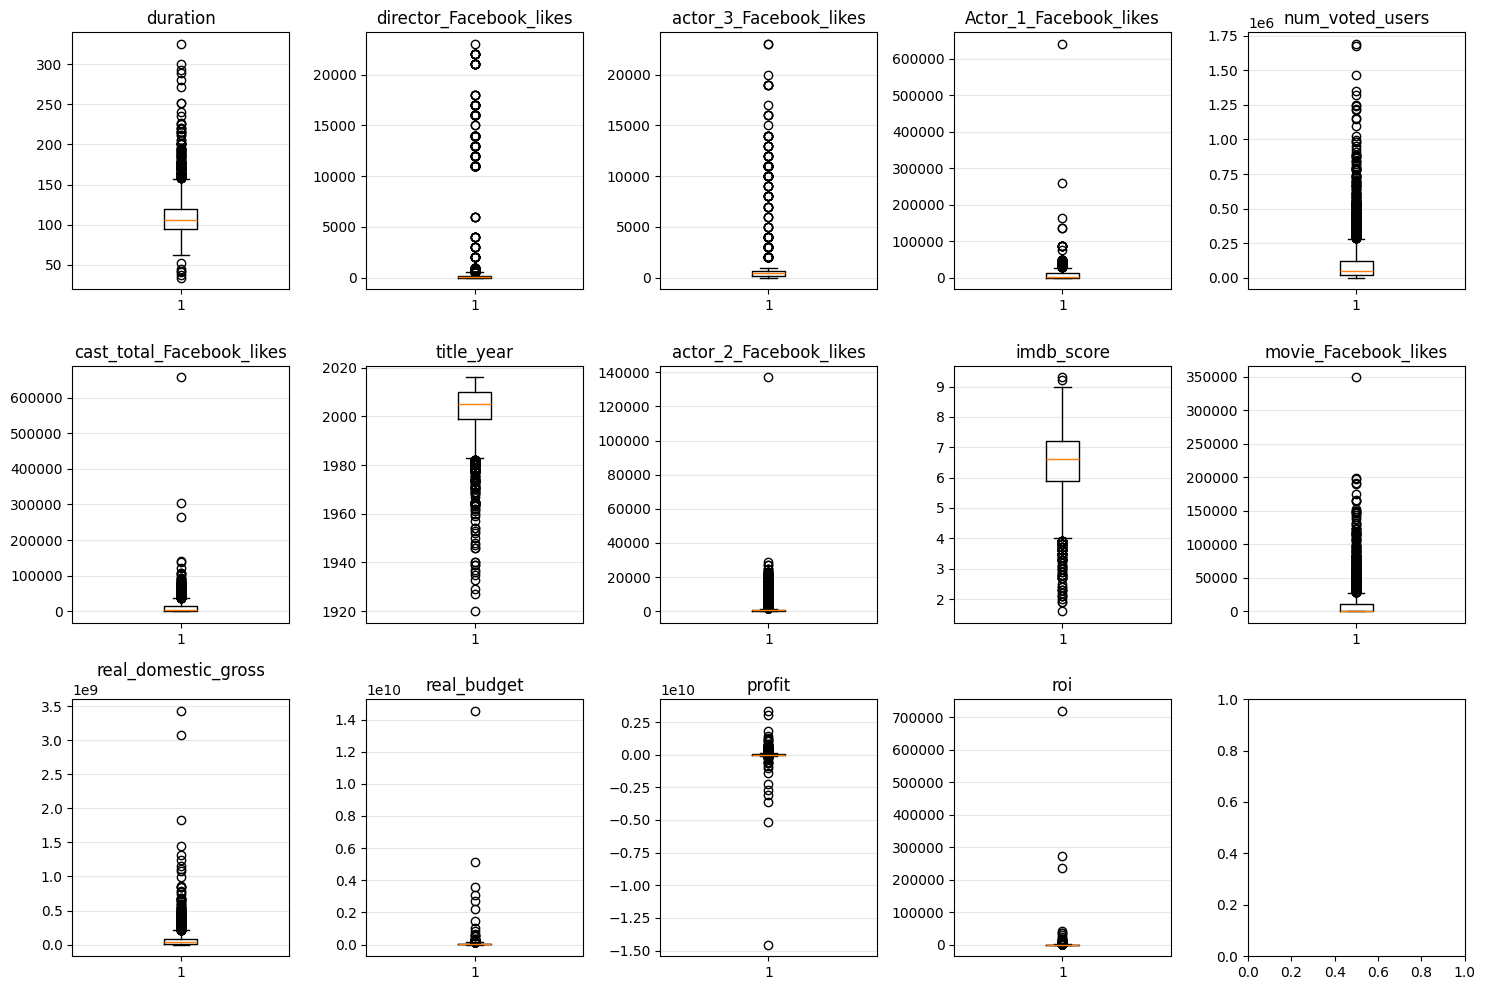

In [104]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(movies_table[col])
    axes[i].set_title(f'{col}')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Проаналихировав boxplots, был сделан вывод, что все значения вписываются в нормальные. "Кажущиеся" выбросы на самом деле являются редкими событями, которые соотвестуют предметной области. Поэтому дальнейшая корректировка данных требует осторожность (данные будут не удаляться и корректировать с использованием `Capping`)

1-2% фильмов составляют 50% и более всей отрасли (к примеру фильм "Аватар" с рекордными сборами) - они и будут показаны выбросами




In [ ]:
df_capped = movies_table.copy()

def cap_outliers_iqr(df, cols, k=1.5, verbose=True):
    for col in cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR_val = Q3 - Q1
        lower, upper = Q1 - k * IQR_val, Q3 + k * IQR_val
        outliers_before = ((df[col] < lower) | (df[col] > upper)).sum()
        df[col] = df[col].clip(lower, upper)
        
        if verbose:
            print(f"{col:30s} | IQR k={k} | Выбросов: {outliers_before:4d}")
    
    return df


k_3_cols = ['real_domestic_gross', 'real_budget', 'profit', 'roi']
df_capped = cap_outliers_iqr(df_capped, k_3_cols, k=3.0)

k_1_5_cols = ['duration']
df_capped = cap_outliers_iqr(df_capped, k_1_5_cols, k=1.5)

fb_cols = [c for c in df_capped.columns if 'Facebook_likes' in c]
df_capped = cap_outliers_iqr(df_capped, fb_cols, k=2.0)

mean = df_capped['imdb_score'].mean()
std = df_capped['imdb_score'].std()
lower, upper = mean - 3*std, mean + 3*std
df_capped['imdb_score'] = df_capped['imdb_score'].clip(lower, upper)

real_domestic_gross            | IQR k=3.0 | Выбросов:  125
real_budget                    | IQR k=3.0 | Выбросов:   48
profit                         | IQR k=3.0 | Выбросов:  192
roi                            | IQR k=3.0 | Выбросов:  220
duration                       | IQR k=1.5 | Выбросов:  127
director_Facebook_likes        | IQR k=2.0 | Выбросов:  344
actor_3_Facebook_likes         | IQR k=2.0 | Выбросов:  165
Actor_1_Facebook_likes         | IQR k=2.0 | Выбросов:   87
cast_total_Facebook_likes      | IQR k=2.0 | Выбросов:  152
actor_2_Facebook_likes         | IQR k=2.0 | Выбросов:  506
movie_Facebook_likes           | IQR k=2.0 | Выбросов:  317


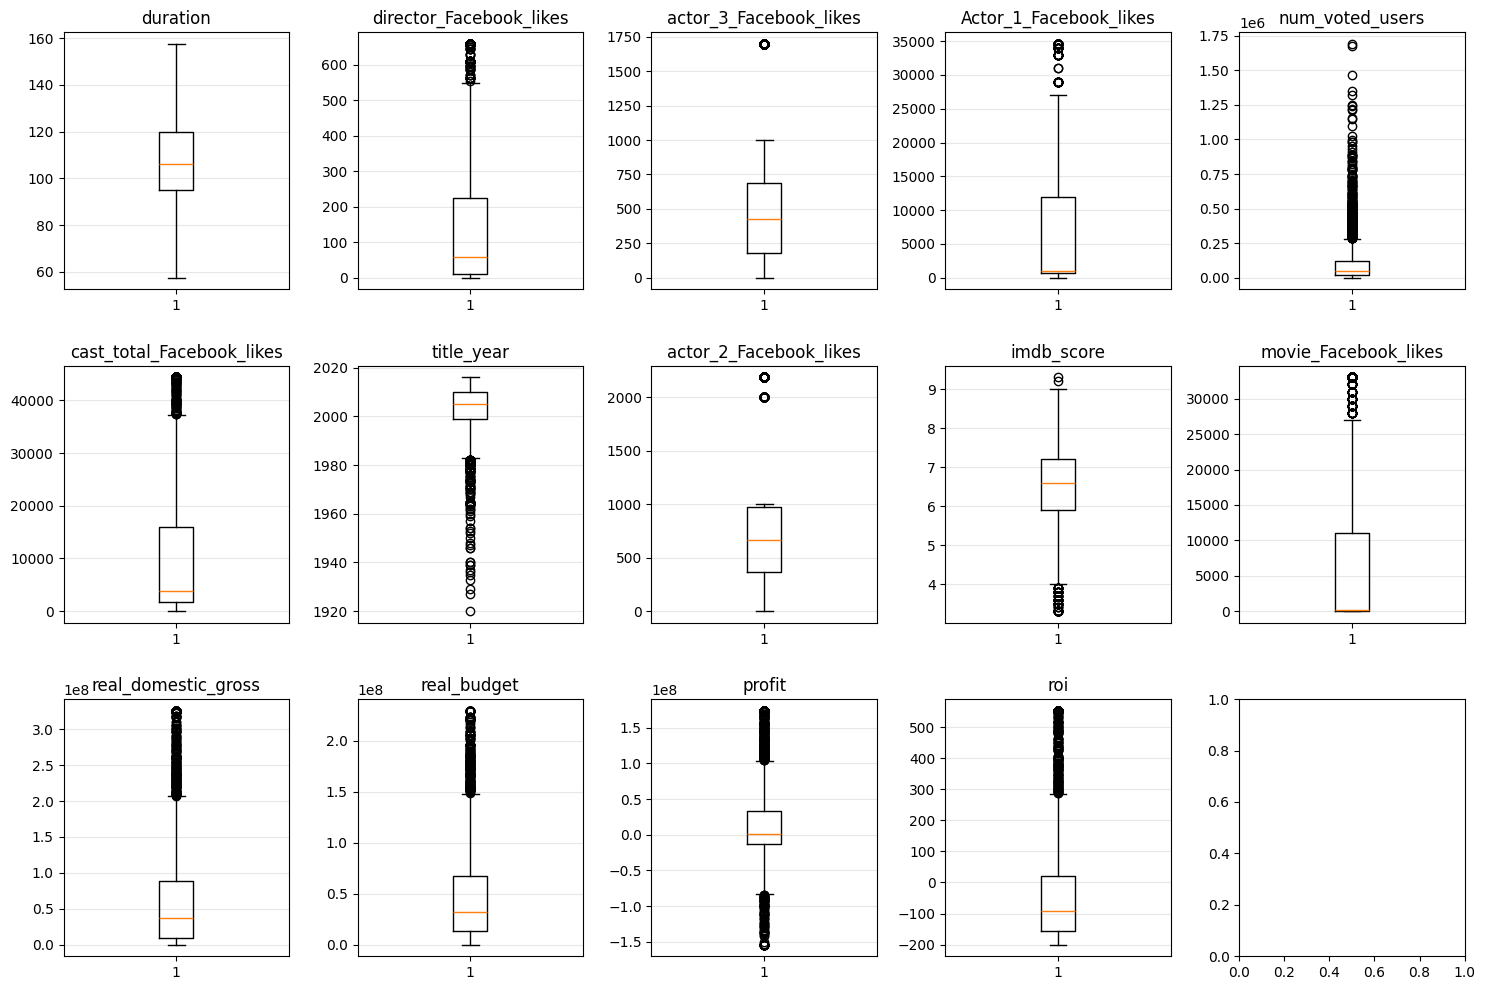

In [106]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df_capped[col])
    axes[i].set_title(f'{col}')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Часть 4: Ответы на вопросы

1. Как распределены рейтинги фильмов (IMDb score)? 
2. Существует ли зависимость между бюджетом фильма и его кассовыми сборами? 
3. Какие жанры встречаются чаще всего? 
4. Влияет ли количество проголосовавших пользователей на итоговый рейтинг? 
5. Есть ли связь между суммарными лайками актёров в Facebook и рейтингом 
фильма? 
6. Как изменялся средний бюджет фильмов по годам? 
7. Какие страны лидируют по количеству произведённых фильмов? 
8. Каково распределение длительности фильмов? 
9. Различаются ли кассовые сборы в зависимости от возрастного рейтинга? 
10. Кто из режиссёров снял больше всего фильмов в данной выборке?


1. **Как распределены рейтинги фильмов (IMDb score)?**

Ответ: Распределение близко к нормальному с пиком около 6,45 - 6,6


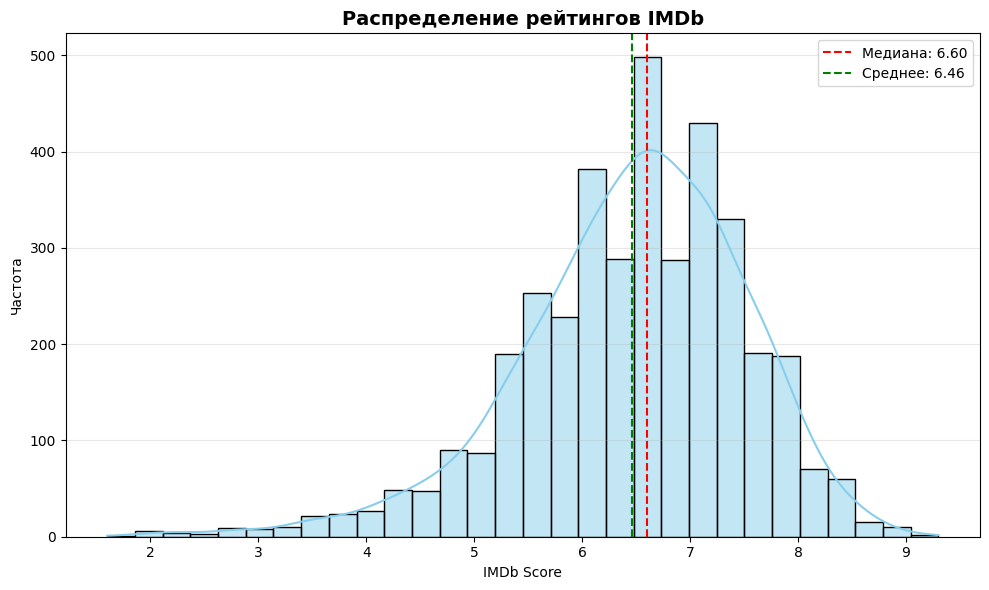

In [107]:
plt.figure(figsize=(10, 6))
sns.histplot(movies_table['imdb_score'], bins=30, kde=True, color='skyblue')
plt.axvline(movies_table['imdb_score'].median(), color='red', linestyle='--', label=f'Медиана: {movies_table["imdb_score"].median():.2f}')
plt.axvline(movies_table['imdb_score'].mean(), color='green', linestyle='--', label=f'Среднее: {movies_table["imdb_score"].mean():.2f}')
plt.title('Распределение рейтингов IMDb', fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score')
plt.ylabel('Частота')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

2. **Существует ли зависимость между бюджетом фильма и его кассовыми сборами?**


Ответ: Положительная корреляция — чем больше бюджет, тем выше сборы.


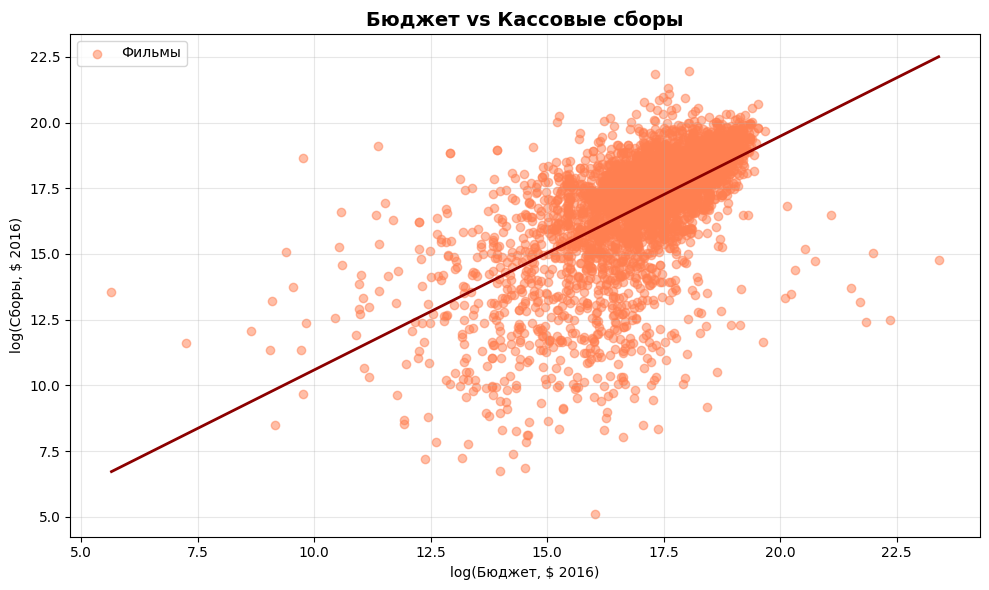

In [108]:
plt.figure(figsize=(10, 6))

x = np.log1p(movies_table['real_budget'])
y = np.log1p(movies_table['real_domestic_gross'])

plt.scatter(x, y, alpha=0.5, color='coral', label='Фильмы')

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='darkred', linewidth=2)

plt.xlabel('log(Бюджет, $ 2016)')
plt.ylabel('log(Сборы, $ 2016)')
plt.title('Бюджет vs Кассовые сборы', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

3. **Какие жанры встречаются чаще всего? **

Ответ: `Dramma` -> `Comedy` -> `Triller` -> ...


C:\Users\danii\AppData\Local\Temp\ipykernel_16836\1893975104.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='Set1')


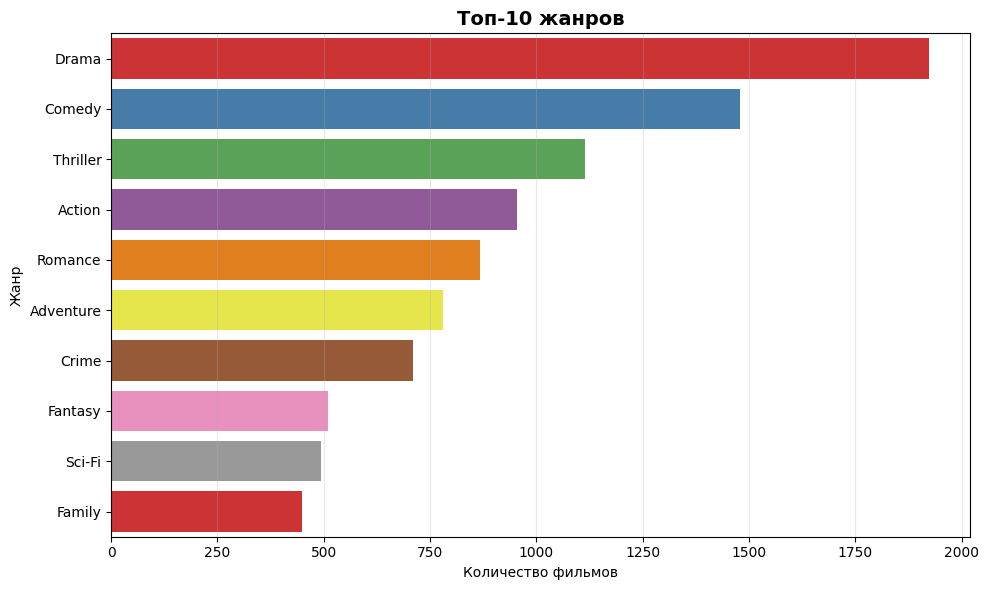

In [109]:
genres_expanded = movies_table['genres'].str.split('|').explode()
top_genres = genres_expanded.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='Set1')
plt.xlabel('Количество фильмов')
plt.ylabel('Жанр')
plt.title('Топ-10 жанров', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

4. **Влияет ли количество проголосовавших пользователей на итоговый рейтинг?**

Ответ: Да, влияет. Положительная корреляция — популярные фильмы часто имеют высокий рейтинг.

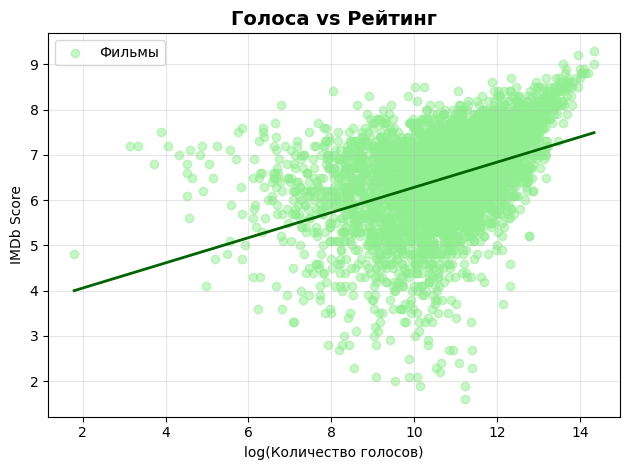

In [110]:
x = np.log1p(movies_table['num_voted_users'])
y = movies_table['imdb_score']

plt.scatter(x, y, alpha=0.5, color='lightgreen', label='Фильмы')

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='darkgreen', linewidth=2)

plt.xlabel('log(Количество голосов)')
plt.ylabel('IMDb Score')
plt.title('Голоса vs Рейтинг', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

5. **Есть ли связь между суммарными лайками актёров в Facebook и рейтингом фильма?**

Ответ: Корреляции практически нет. Эти показатели не связаны.

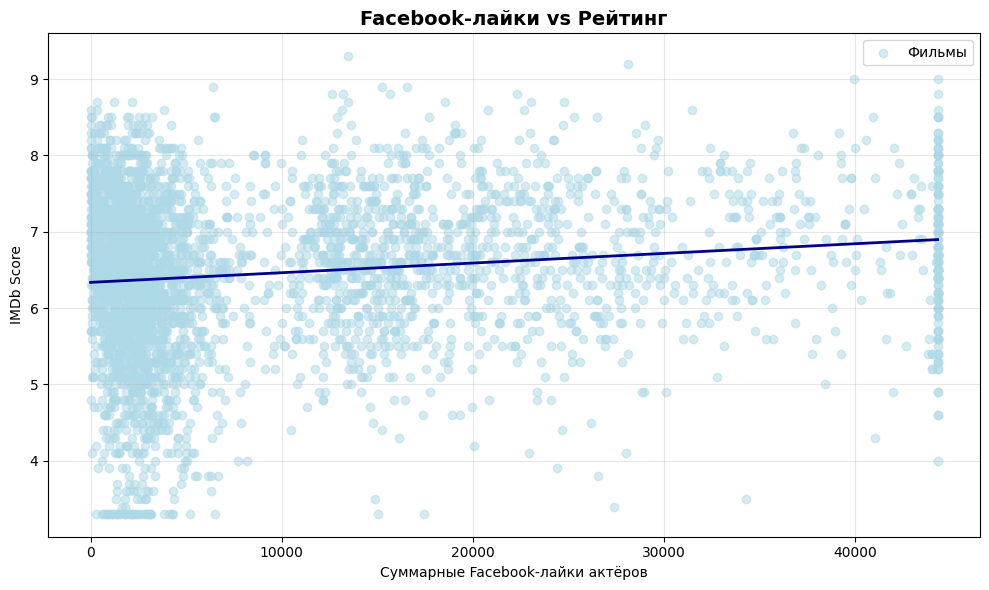

In [111]:
plt.figure(figsize=(10, 6))

x = df_capped['cast_total_Facebook_likes']
y = df_capped['imdb_score']

plt.scatter(x, y, alpha=0.5, color='lightblue', label='Фильмы')

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept
plt.plot(x_line, y_line, color='darkblue', linewidth=2)

plt.xlabel('Суммарные Facebook-лайки актёров')
plt.ylabel('IMDb Score')
plt.title('Facebook-лайки vs Рейтинг', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

6. **Как изменялся средний бюджет фильмов по годам**

Ответ: Динамика медианного бюджета фильмов (1920–2016):

- 1920–1930-е: Бюджеты быстро росли — киноиндустрия развивалась.
- 1940–1970-е: Стабилизация на уровне ~20 млн $ (в ценах 2016 г.), но с сильными колебаниями от года к году.
- 1980–2016: Постепенное снижение до ~17 млн $ и стабилизация — баланс между дорогими блокбастерами и дешёвым независимым кино.
Итог: За 100 лет медианный бюджет вырос очень незначительно (около 0,5 млн долларов). Это значит, что, несмотря на рост индустрии, «средний» фильм по-прежнему снимается за примерно те же деньги (с поправкой на инфляцию).


C:\Users\danii\AppData\Local\Temp\ipykernel_16836\2132016745.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


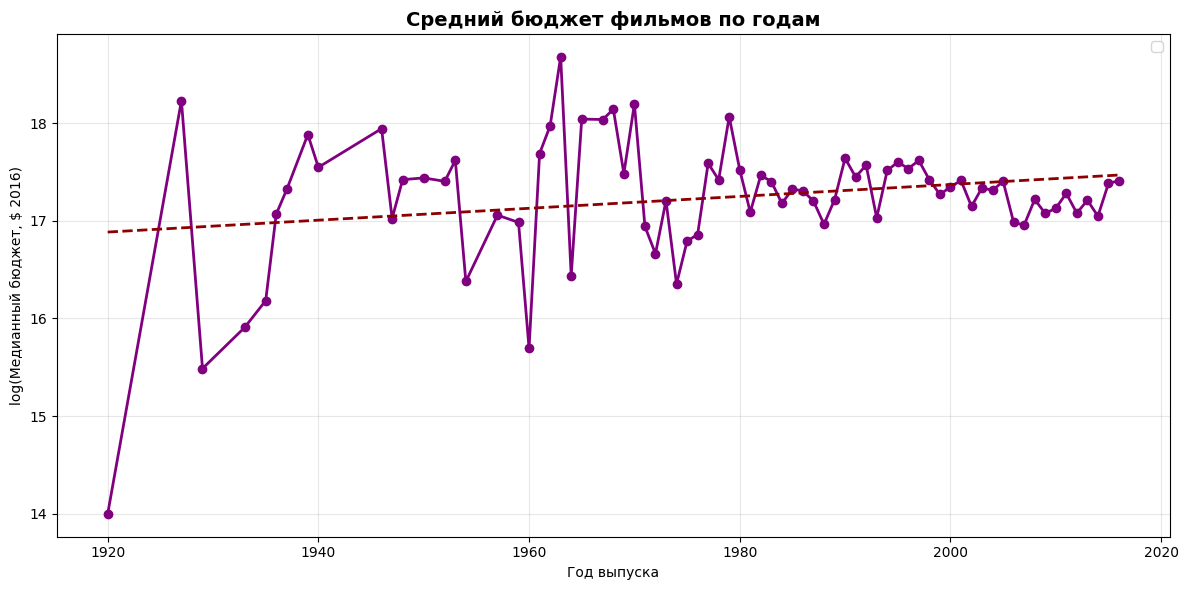

In [112]:
plt.figure(figsize=(12, 6))

budget_by_year = movies_table.groupby('title_year')['real_budget'].median()
x = budget_by_year.index.astype(float)
y = np.log1p(budget_by_year.values)

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
y_trend = slope * x + intercept

plt.plot(x, np.log1p(budget_by_year.values), marker='o', color='purple', linewidth=2)

plt.plot(x, y_trend, color='darkred', linestyle='--', linewidth=2)

plt.xlabel('Год выпуска')
plt.ylabel('log(Медианный бюджет, $ 2016)')
plt.title('Средний бюджет фильмов по годам', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


7. **Какие страны лидируют по количеству произведённых фильмов?**

Ответ: `USA` (неоспоримый лидер) -> `UK` -> `France` -> ...

C:\Users\danii\AppData\Local\Temp\ipykernel_16836\2474359701.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Set1')


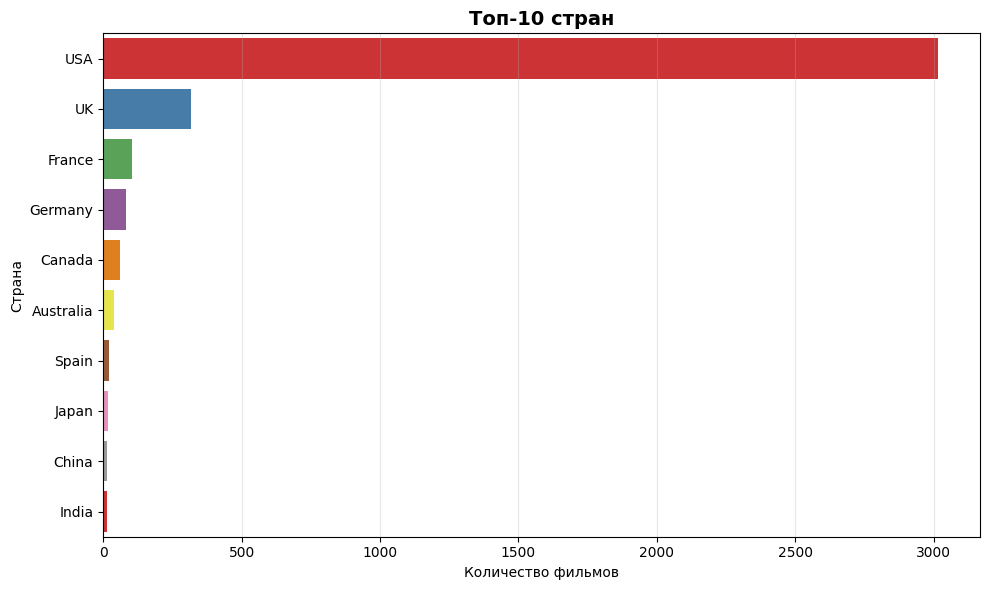

In [113]:
top_countries = movies_table['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Set1')
plt.xlabel('Количество фильмов')
plt.ylabel('Страна')
plt.title('Топ-10 стран', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

8. **Каково распределение длительности фильмов?**

Ответ:  Большинство фильмов идут в районе 106 минут (90-120)

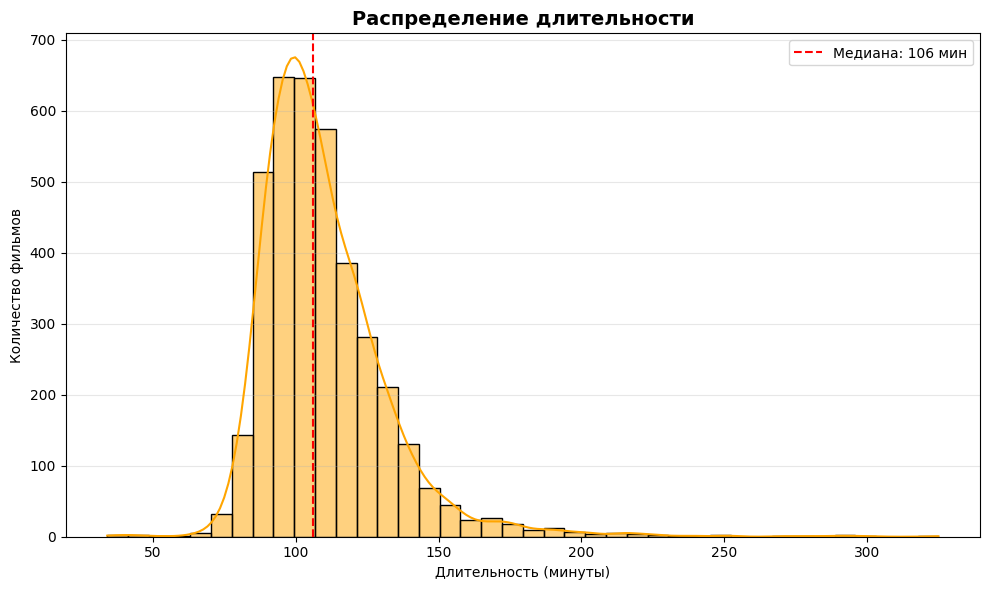

In [114]:
plt.figure(figsize=(10, 6))
sns.histplot(movies_table['duration'], bins=40, kde=True, color='orange')
plt.axvline(movies_table['duration'].median(), color='red', linestyle='--', label=f'Медиана: {movies_table["duration"].median():.0f} мин')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Количество фильмов')
plt.title('Распределение длительности', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

9. **Различаются ли кассовые сборы в зависимости от возрастного рейтинга?**

Ответ: По графику видно, что с увелечением возростного рейтинга, сборы падают


C:\Users\danii\AppData\Local\Temp\ipykernel_16836\3882315050.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=median_gross_by_rating.index,


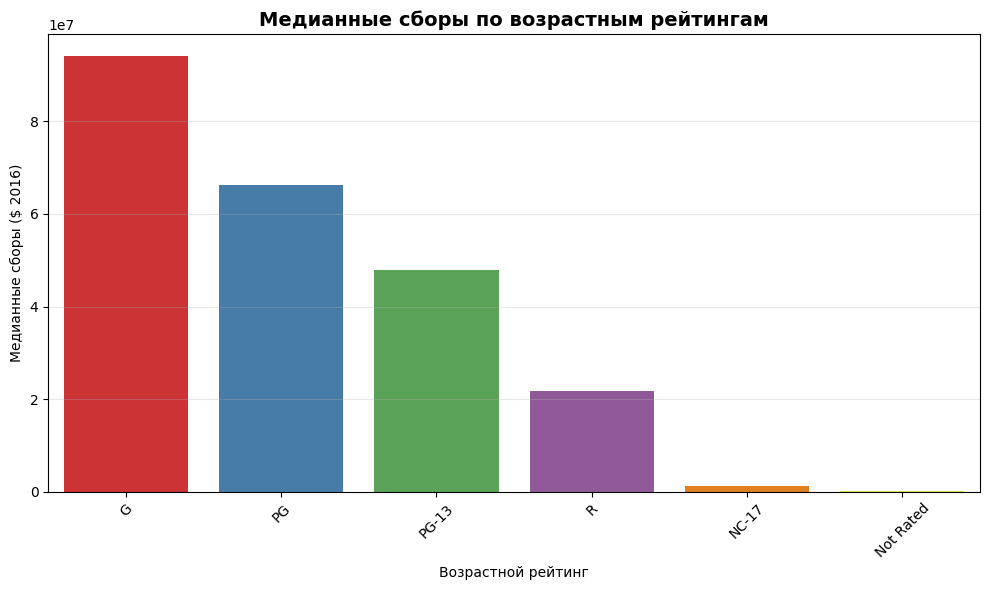

In [115]:
plt.figure(figsize=(10, 6))
rating_order = ['G', 'PG', 'PG-13', 'R', 'NC-17','Approved', 'Not Rated']
ratings_present = [r for r in rating_order if r in movies_table['content_rating'].unique()]

median_gross_by_rating = movies_table.groupby('content_rating')['real_domestic_gross'].median()

sns.barplot(x=median_gross_by_rating.index, 
            y=median_gross_by_rating.values, 
            palette='Set1',
            order=ratings_present)

plt.xlabel('Возрастной рейтинг')
plt.ylabel('Медианные сборы ($ 2016)')
plt.title('Медианные сборы по возрастным рейтингам', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

10. **Кто из режиссёров снял больше всего фильмов в данной выборке?**

Ответ: `Steven Spielberg`

C:\Users\danii\AppData\Local\Temp\ipykernel_16836\3580540826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='Set1')


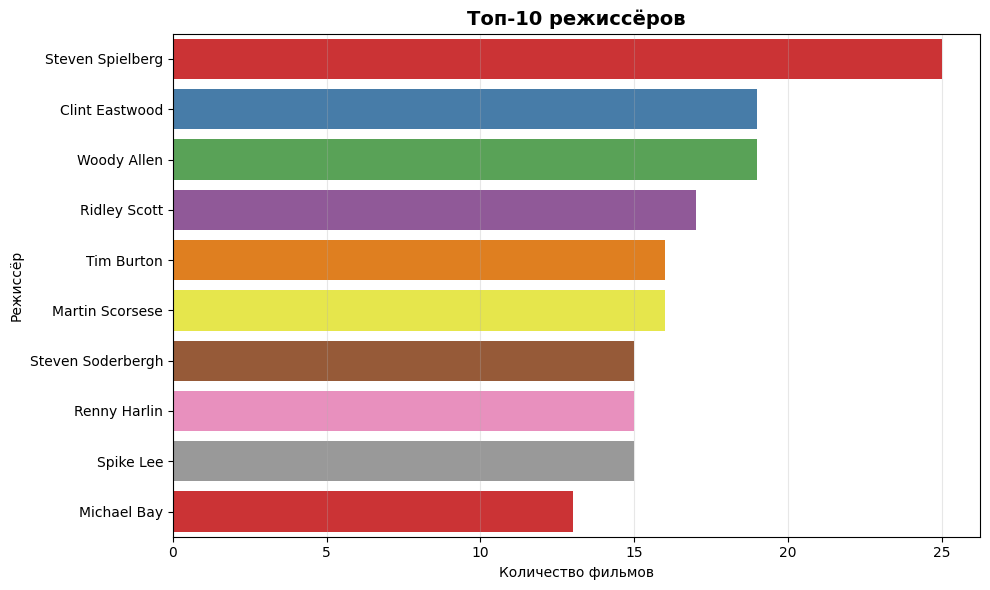

In [116]:
top_directors = movies_table['Director_Name'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='Set1')
plt.xlabel('Количество фильмов')
plt.ylabel('Режиссёр')
plt.title('Топ-10 режиссёров', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Итоговые ответы**


1. **Как распределены рейтинги фильмов (IMDb score)?**

Ответ: Распределение близко к нормальному с пиком около 6,45 - 6,6


2. **Существует ли зависимость между бюджетом фильма и его кассовыми сборами?**


Ответ: Положительная корреляция — чем больше бюджет, тем выше сборы.


3. **Какие жанры встречаются чаще всего? **

Ответ: `Dramma` -> `Comedy` -> `Triller` -> ...


4. **Влияет ли количество проголосовавших пользователей на итоговый рейтинг?**

Ответ: Да, влияет. Положительная корреляция — популярные фильмы часто имеют высокий рейтинг.

5. **Есть ли связь между суммарными лайками актёров в Facebook и рейтингом фильма?**

Ответ: Корреляции практически нет. Эти показатели не связаны.

6. **Как изменялся средний бюджет фильмов по годам**

Ответ: Динамика медианного бюджета фильмов (1920–2016):

- 1920–1930-е: Бюджеты быстро росли — киноиндустрия развивалась.
- 1940–1970-е: Стабилизация на уровне ~20 млн $ (в ценах 2016 г.), но с сильными колебаниями от года к году.
- 1980–2016: Постепенное снижение до ~17 млн $ и стабилизация — баланс между дорогими блокбастерами и дешёвым независимым кино.
Итог: За 100 лет медианный бюджет вырос очень незначительно (около 0,5 млн долларов). Это значит, что, несмотря на рост индустрии, «средний» фильм по-прежнему снимается за примерно те же деньги (с поправкой на инфляцию).


7. **Какие страны лидируют по количеству произведённых фильмов?**

Ответ: `USA` (неоспоримый лидер) -> `UK` -> `France` -> ...

8. **Каково распределение длительности фильмов?**

Ответ:  Большинство фильмов идут в районе 106 минут (90-120)

9. **Различаются ли кассовые сборы в зависимости от возрастного рейтинга?**

Ответ: По графику видно, что с увелечением возростного рейтинга, сборы падают


10. **Кто из режиссёров снял больше всего фильмов в данной выборке?**

Ответ: `Steven Spielberg`